<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
# !pip install pandas 
# !pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
# !wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


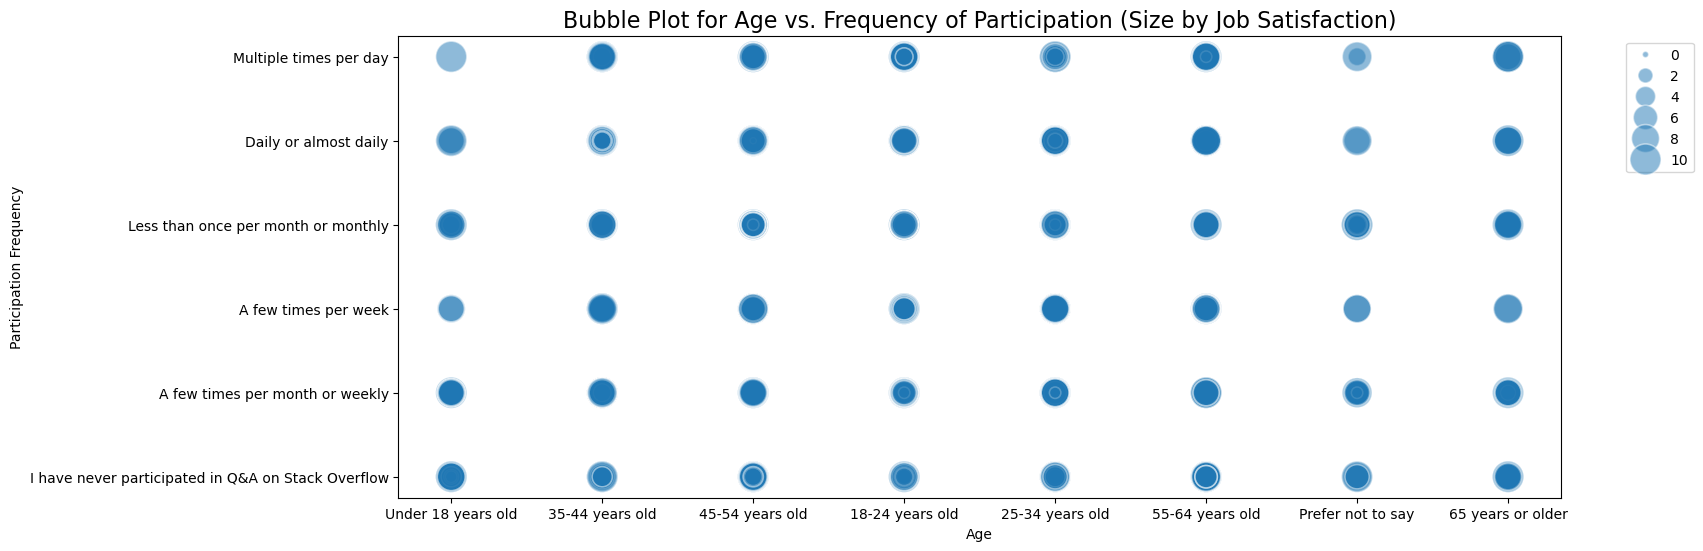

In [3]:
##Write your code here
plt.figure(figsize = (15, 6))
sns.scatterplot(data = df, x = 'Age', y = 'SOPartFreq', 
                size = 'JobSat', sizes = (20, 500), alpha = 0.5)
plt.xlabel('Age')
plt.ylabel('Participation Frequency')
plt.title('Bubble Plot for Age vs. Frequency of Participation (Size by Job Satisfaction)', fontsize =  16)
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


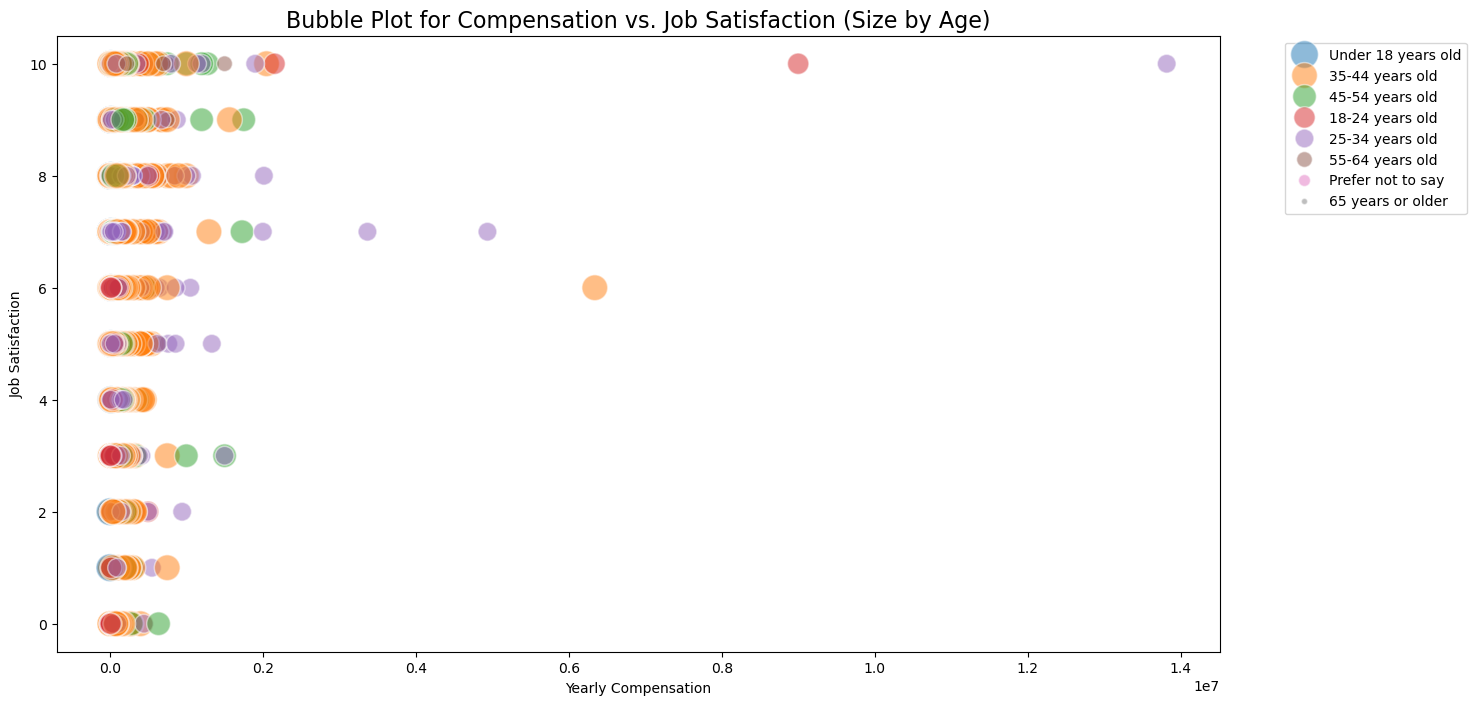

In [4]:
##Write your code here
plt.figure(figsize = (15, 8))
sns.scatterplot(data = df, x = 'ConvertedCompYearly', y = 'JobSat', 
                size = 'Age', sizes = (20, 400), hue = 'Age', alpha = 0.5)
plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction')
plt.title('Bubble Plot for Compensation vs. Job Satisfaction (Size by Age)', fontsize = 16)
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



In [5]:
##Write your code here
languages_df = df[['Age', 'LanguageHaveWorkedWith']].dropna()
languages_df['Language'] = languages_df['LanguageHaveWorkedWith'].str.split(';')
languages_df = languages_df.explode('Language')
languages_df

,Age,LanguageHaveWorkedWith,Language
1,35-44 years old,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells)
1,35-44 years old,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Go
1,35-44 years old,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,HTML/CSS
1,35-44 years old,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Java
1,35-44 years old,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,JavaScript
...,...,...,...
65436,18-24 years old,C;HTML/CSS;Java;JavaScript;PHP;Python;TypeScript,Java
65436,18-24 years old,C;HTML/CSS;Java;JavaScript;PHP;Python;TypeScript,JavaScript
65436,18-24 years old,C;HTML/CSS;Java;JavaScript;PHP;Python;TypeScript,PHP
65436,18-24 years old,C;HTML/CSS;Java;JavaScript;PHP;Python;TypeScript,Python


In [6]:
lang_counts = languages_df.groupby(['Age', 'Language']).size().reset_index(name = 'Count')

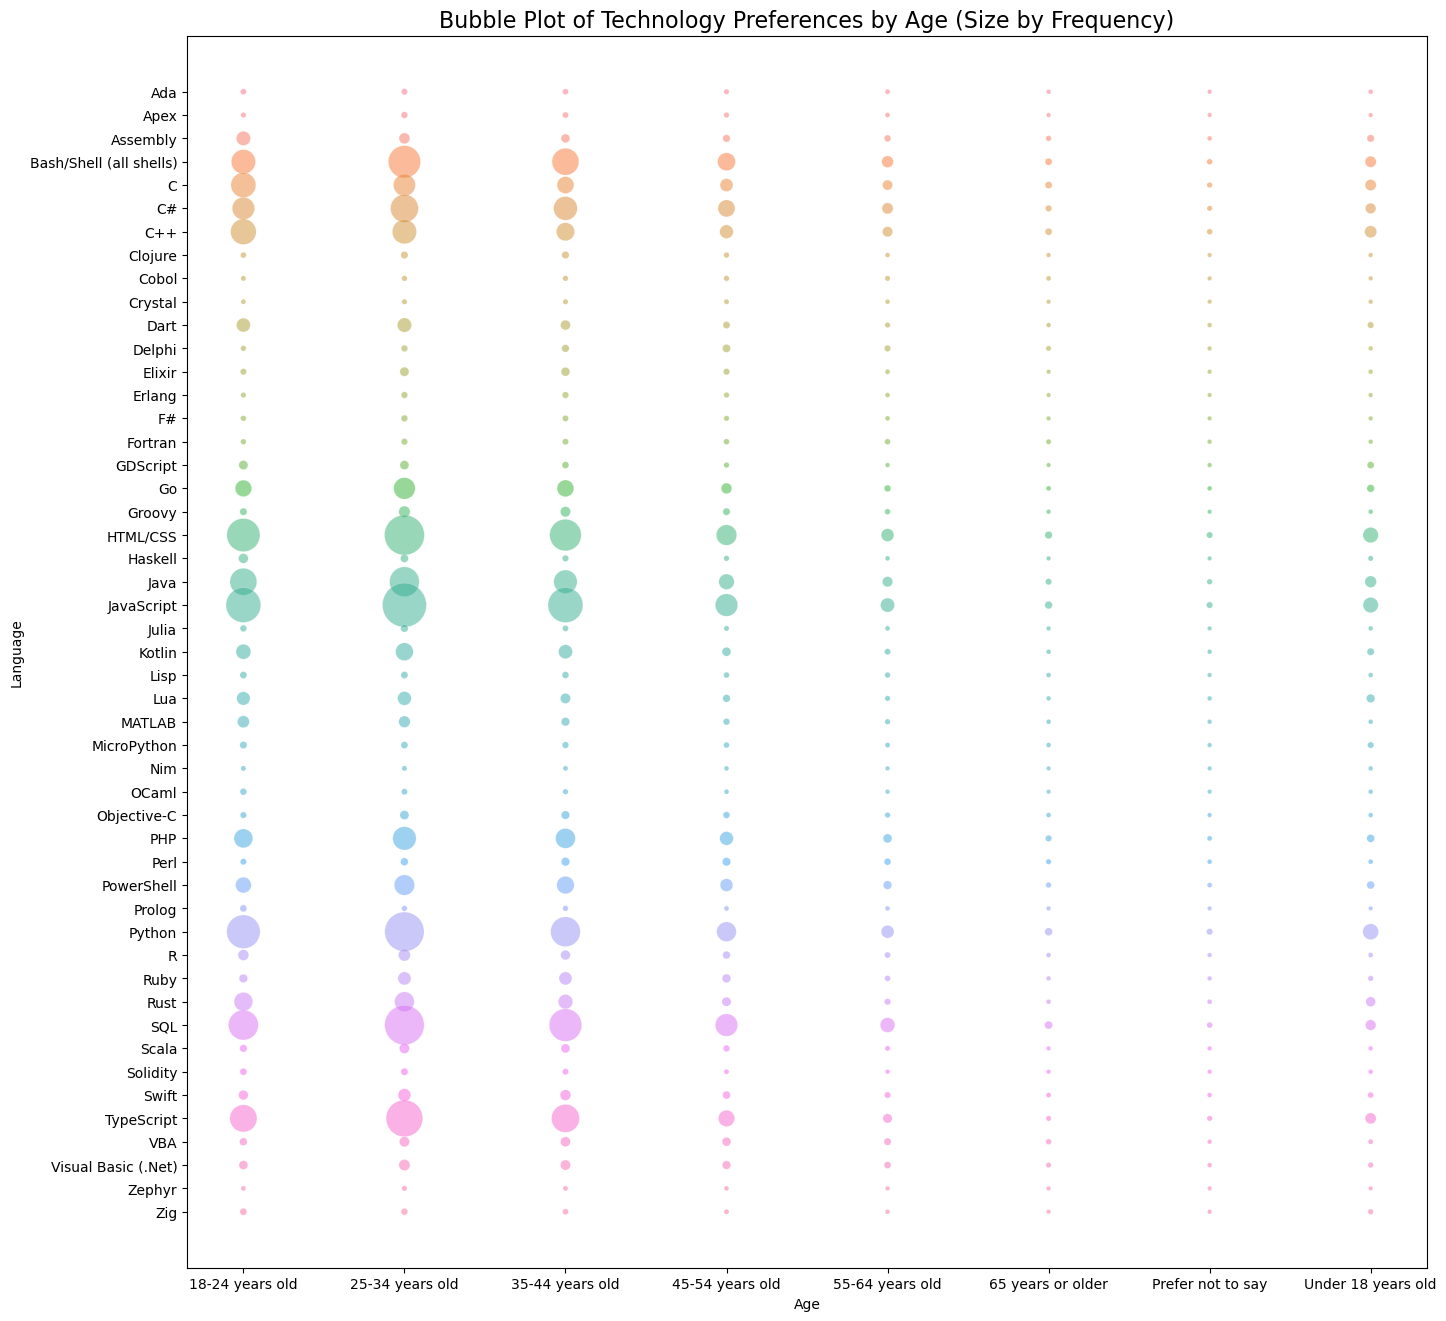

In [7]:
plt.figure(figsize = (16, 16))
sns.scatterplot(data = lang_counts, x = 'Age', y = 'Language', 
                size = 'Count', sizes = (10, 1000), hue = 'Language', legend = False, alpha = 0.5)
plt.title('Bubble Plot of Technology Preferences by Age (Size by Frequency)', fontsize = 16)
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


In [8]:
##Write your code here
db_df = df[['DatabaseWantToWorkWith', 'JobSat']].dropna()
db_df['Database'] = db_df['DatabaseWantToWorkWith'].str.split(';')
db_df = db_df.explode('Database')
db_df

,DatabaseWantToWorkWith,JobSat,Database
10,Elasticsearch;MongoDB;PostgreSQL;SQLite,8.0,Elasticsearch
10,Elasticsearch;MongoDB;PostgreSQL;SQLite,8.0,MongoDB
10,Elasticsearch;MongoDB;PostgreSQL;SQLite,8.0,PostgreSQL
10,Elasticsearch;MongoDB;PostgreSQL;SQLite,8.0,SQLite
12,MySQL,8.0,MySQL
...,...,...,...
65351,Cassandra;Firebase Realtime Database;MariaDB;M...,8.0,Microsoft Access
65351,Cassandra;Firebase Realtime Database;MariaDB;M...,8.0,MongoDB
65351,Cassandra;Firebase Realtime Database;MariaDB;M...,8.0,MySQL
65351,Cassandra;Firebase Realtime Database;MariaDB;M...,8.0,PostgreSQL


In [9]:
db_counts = db_df.groupby(['Database', 'JobSat']).size().reset_index(name = 'Count')

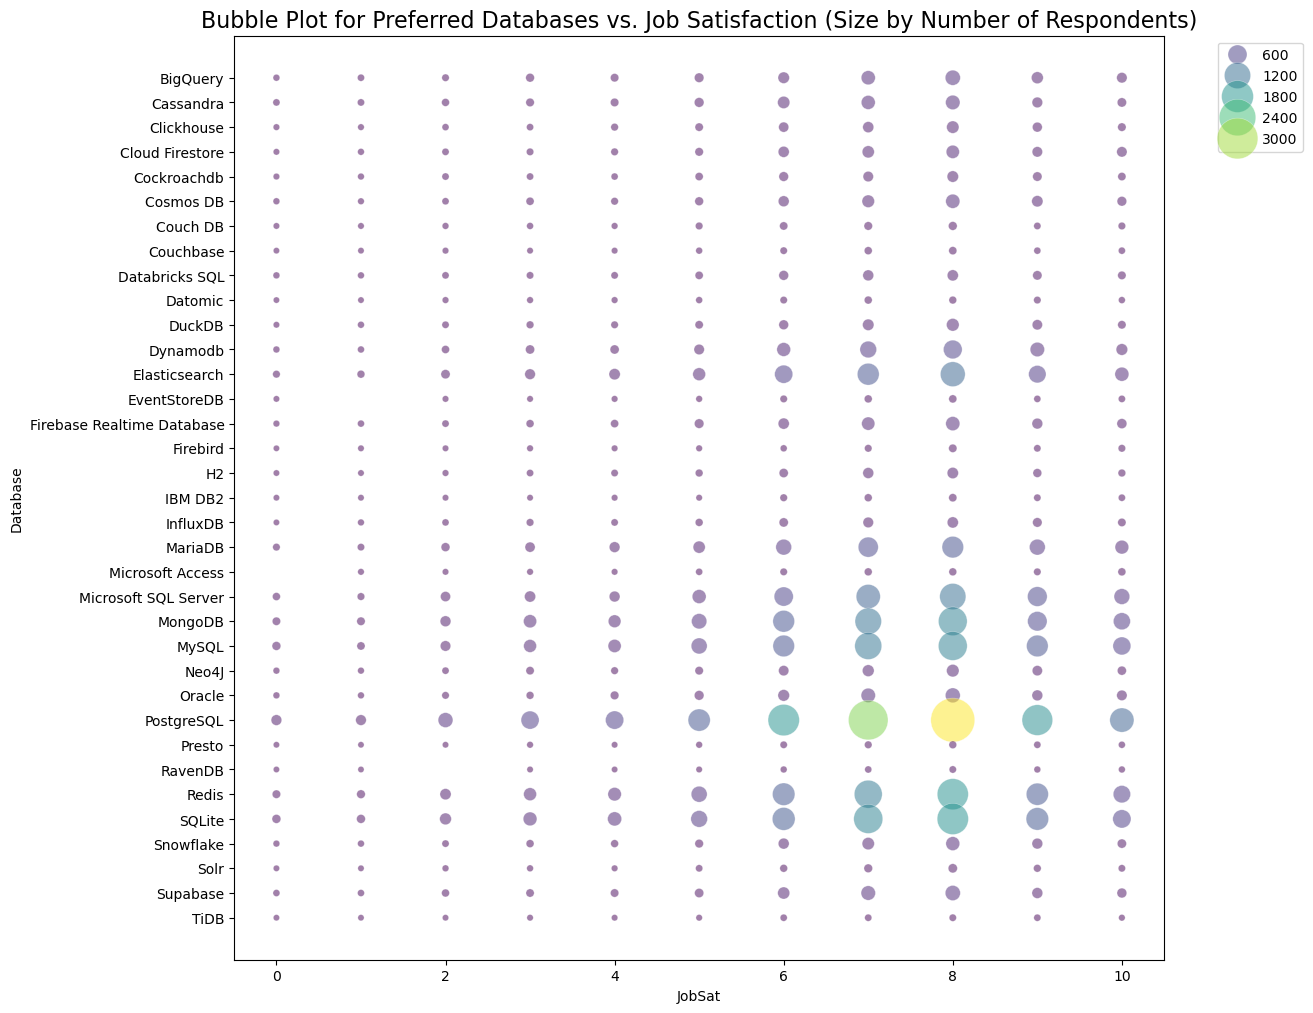

In [10]:
plt.figure(figsize=(12, 12))
sns.scatterplot(data = db_counts, x = 'JobSat', y = 'Database', 
                size = 'Count', sizes = (20, 1000), hue = 'Count', palette = 'viridis', alpha = 0.5)
plt.title('Bubble Plot for Preferred Databases vs. Job Satisfaction (Size by Number of Respondents)', fontsize = 16)
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


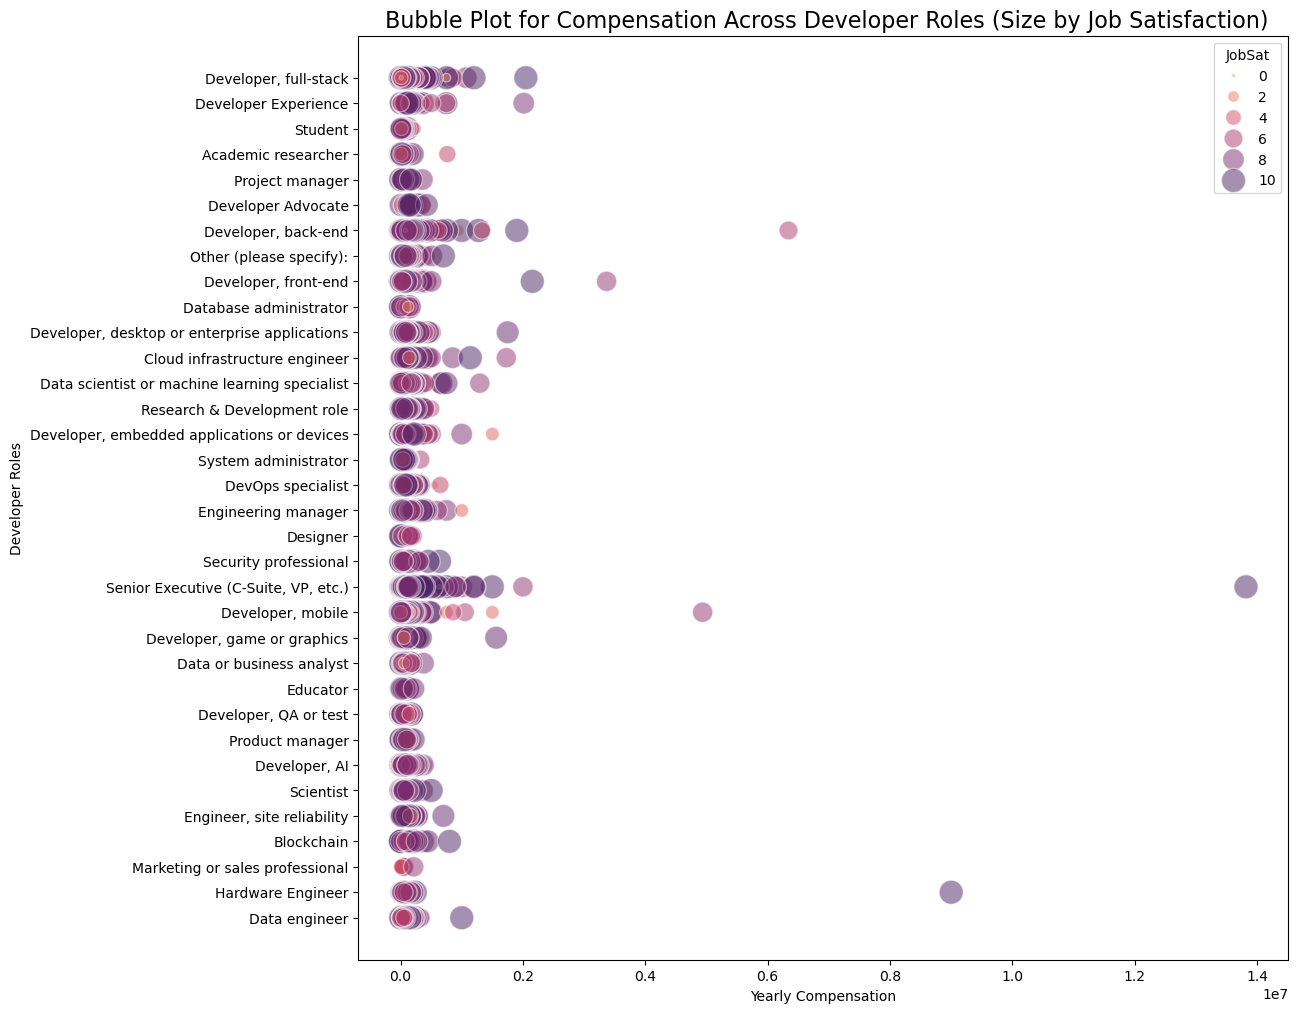

In [11]:
##Write your code here
plt.figure(figsize=(12, 12))
sns.scatterplot(data = df, x = 'ConvertedCompYearly', y = 'DevType', 
                size = 'JobSat', sizes = (10, 300), hue = 'JobSat', alpha = 0.5, palette = 'flare')
plt.xlabel('Yearly Compensation')
plt.ylabel('Developer Roles')
plt.title(' Bubble Plot for Compensation Across Developer Roles (Size by Job Satisfaction)', fontsize = 16)
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


In [12]:
##Write your code here
collab_df = df[['NEWCollabToolsHaveWorkedWith', 'Age']].dropna()
collab_df['Tool'] = collab_df['NEWCollabToolsHaveWorkedWith'].str.split(';')
collab_df = collab_df.explode('Tool')
tool_counts = collab_df.groupby(['Age', 'Tool']).size().reset_index(name = 'Frequency')
tool_counts

,Age,Tool,Frequency
0,18-24 years old,Android Studio,2663
1,18-24 years old,BBEdit,35
2,18-24 years old,CLion,1168
3,18-24 years old,Code::Blocks,531
4,18-24 years old,DataGrip,709
...,...,...,...
274,Under 18 years old,Vim,438
275,Under 18 years old,Visual Studio,780
276,Under 18 years old,Visual Studio Code,1808
277,Under 18 years old,WebStorm,155


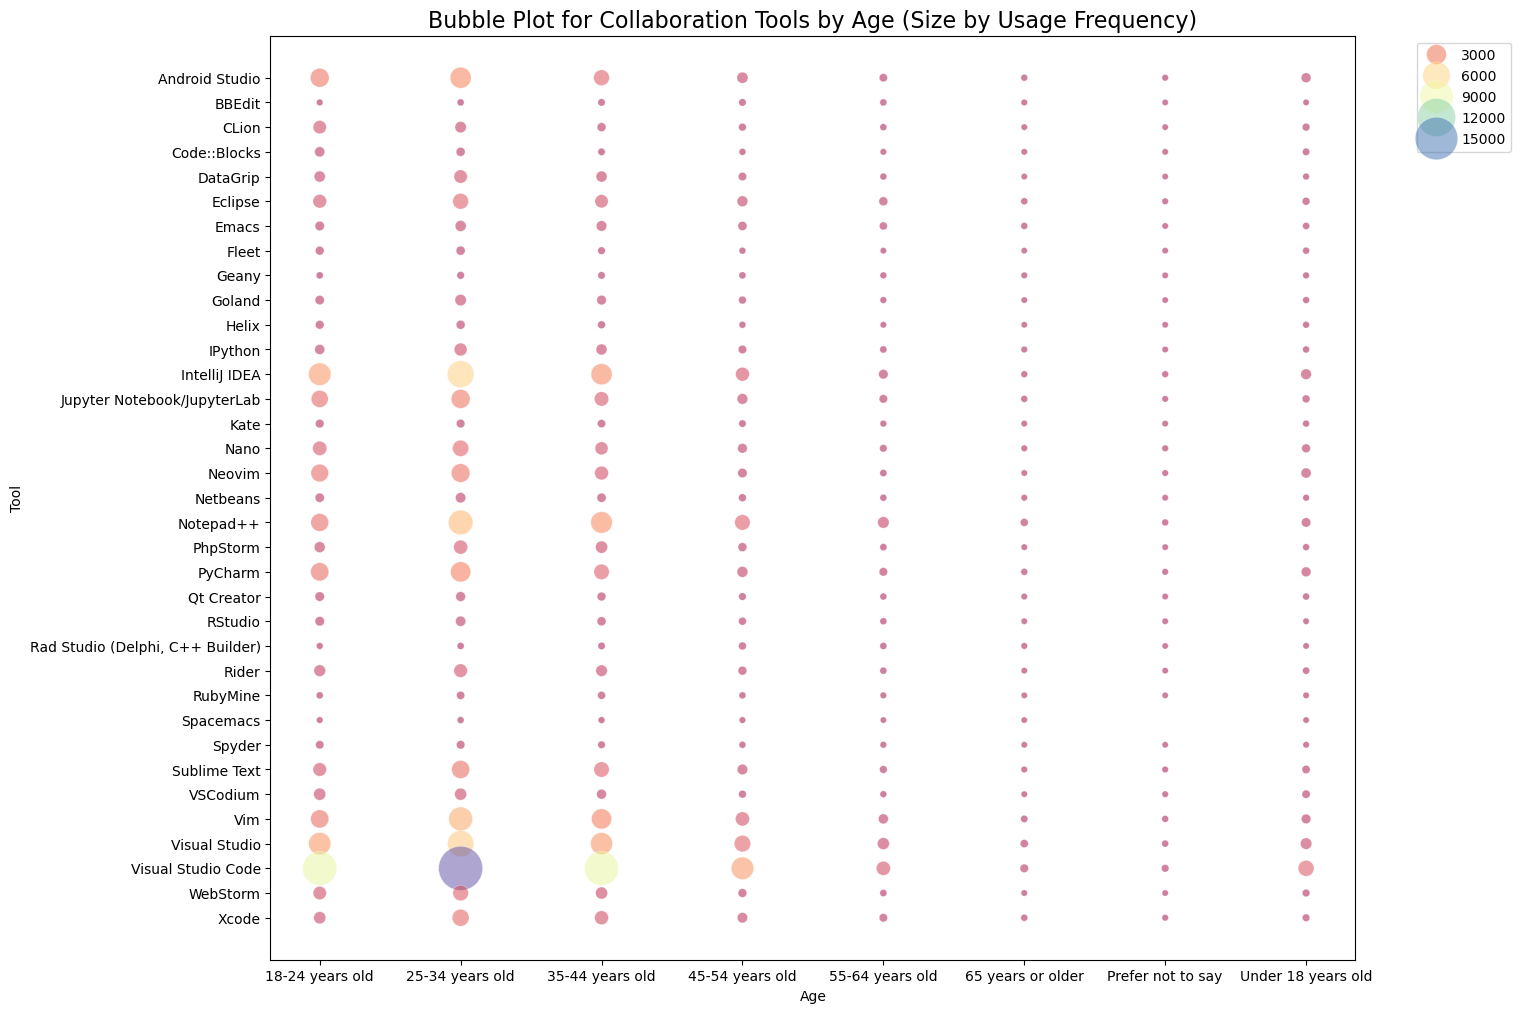

In [13]:
plt.figure(figsize=(14, 12))
sns.scatterplot(data = tool_counts, x = 'Age', y = 'Tool', 
                size = 'Frequency', sizes=(20, 1000), hue = 'Frequency', alpha = 0.5, palette = 'Spectral')
plt.title('Bubble Plot for Collaboration Tools by Age (Size by Usage Frequency)', fontsize = 16)
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



In [14]:
##Write your code here
web_df = df[['WebframeWantToWorkWith', 'JobSat']].dropna()
web_df['Framework'] = web_df['WebframeWantToWorkWith'].str.split(';')
web_df = web_df.explode('Framework')
web_df

,WebframeWantToWorkWith,JobSat,Framework
10,Django;Node.js;React;Ruby on Rails,8.0,Django
10,Django;Node.js;React;Ruby on Rails,8.0,Node.js
10,Django;Node.js;React;Ruby on Rails,8.0,React
10,Django;Node.js;React;Ruby on Rails,8.0,Ruby on Rails
15,Blazor,5.0,Blazor
...,...,...,...
65351,Django;Express;Laravel;NestJS;Next.js;Node.js;...,8.0,React
65351,Django;Express;Laravel;NestJS;Next.js;Node.js;...,8.0,Spring Boot
65351,Django;Express;Laravel;NestJS;Next.js;Node.js;...,8.0,Symfony
65351,Django;Express;Laravel;NestJS;Next.js;Node.js;...,8.0,Vue.js


In [15]:
web_counts = web_df.groupby(['Framework', 'JobSat']).size().reset_index(name = 'Respondents')
web_counts

,Framework,JobSat,Respondents
0,ASP.NET,0.0,20
1,ASP.NET,1.0,19
2,ASP.NET,2.0,48
3,ASP.NET,3.0,57
4,ASP.NET,4.0,73
...,...,...,...
391,jQuery,6.0,284
392,jQuery,7.0,421
393,jQuery,8.0,529
394,jQuery,9.0,288


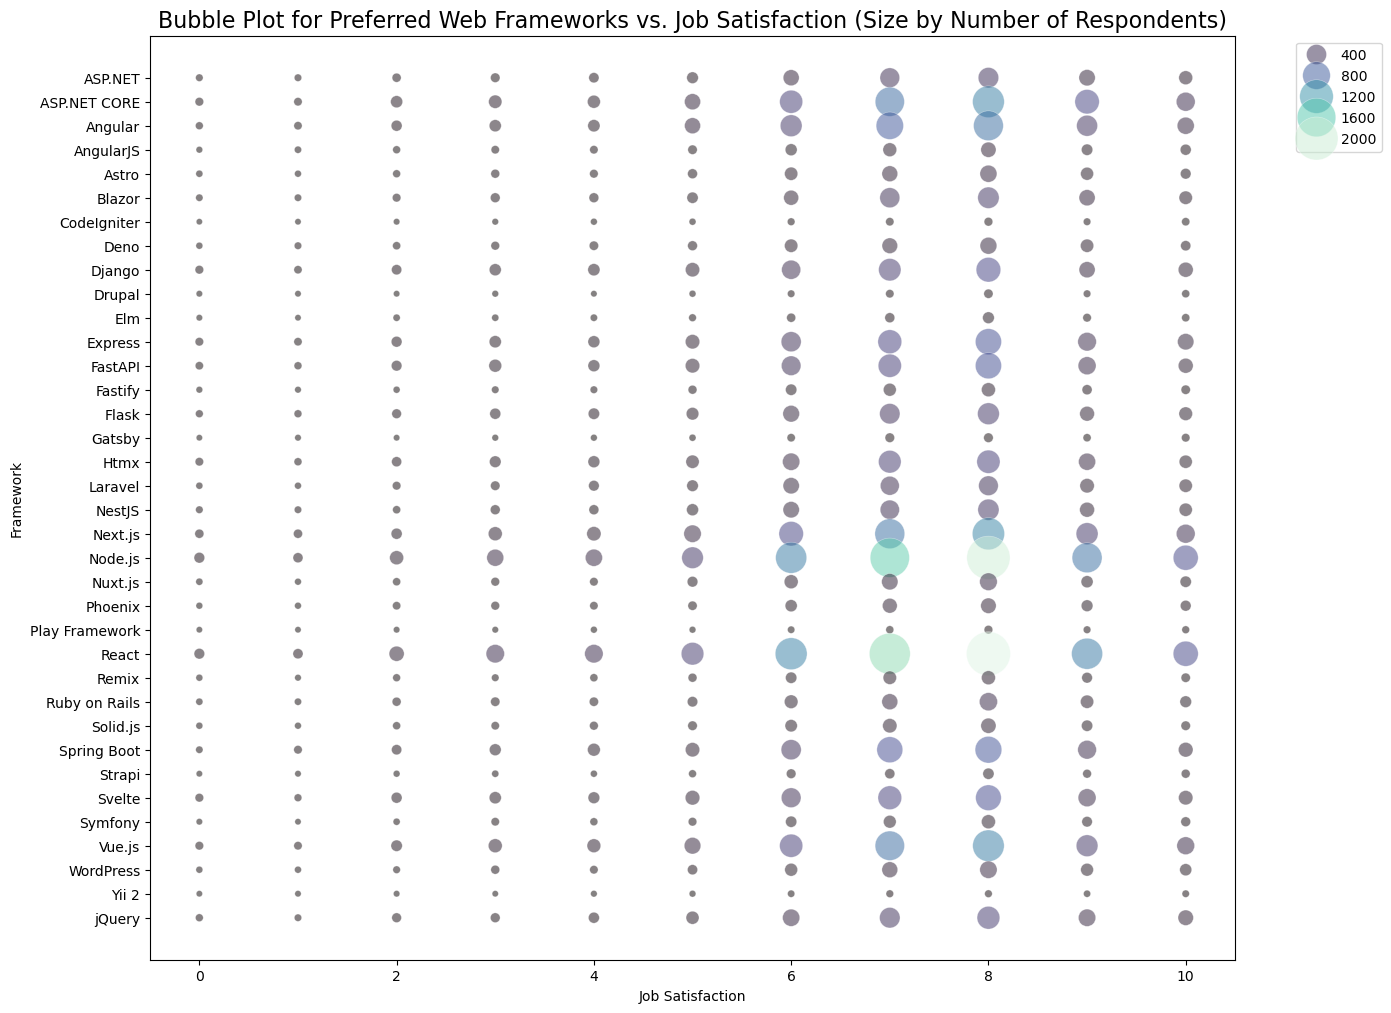

In [16]:
plt.figure(figsize = (14, 12))
sns.scatterplot(data = web_counts, x = 'JobSat', y = 'Framework',
                size = 'Respondents', sizes = (20, 1000), hue = 'Respondents', palette = 'mako', alpha = 0.5)
plt.xlabel('Job Satisfaction')
plt.title('Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction (Size by Number of Respondents)', fontsize = 16),
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



In [17]:
##Write your code here
top_countries = df['Country'].value_counts().nlargest(10).index
filtered_df = df[df['Country'].isin(top_countries)]

In [18]:
admired_df = filtered_df[['LanguageAdmired', 'Country']].dropna()
admired_df['Language'] = admired_df['LanguageAdmired'].str.split(';')
admired_df = admired_df.explode('Language')
admired_df

,LanguageAdmired,Country,Language
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,United Kingdom of Great Britain and Northern I...,Bash/Shell (all shells)
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,United Kingdom of Great Britain and Northern I...,Go
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,United Kingdom of Great Britain and Northern I...,HTML/CSS
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,United Kingdom of Great Britain and Northern I...,Java
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,United Kingdom of Great Britain and Northern I...,JavaScript
...,...,...,...
65401,C#;HTML/CSS;JavaScript;SQL;TypeScript,France,TypeScript
65408,Python;SQL,France,Python
65408,Python;SQL,France,SQL
65435,Rust;SQL,Germany,Rust


In [19]:
admired_counts = admired_df.groupby(['Country', 'Language']).size().reset_index(name = 'Frequency')
admired_counts

,Country,Language,Frequency
0,Brazil,Ada,2
1,Brazil,Apex,12
2,Brazil,Assembly,18
3,Brazil,Bash/Shell (all shells),269
4,Brazil,C,102
...,...,...,...
480,United States of America,TypeScript,2767
481,United States of America,VBA,112
482,United States of America,Visual Basic (.Net),127
483,United States of America,Zephyr,18


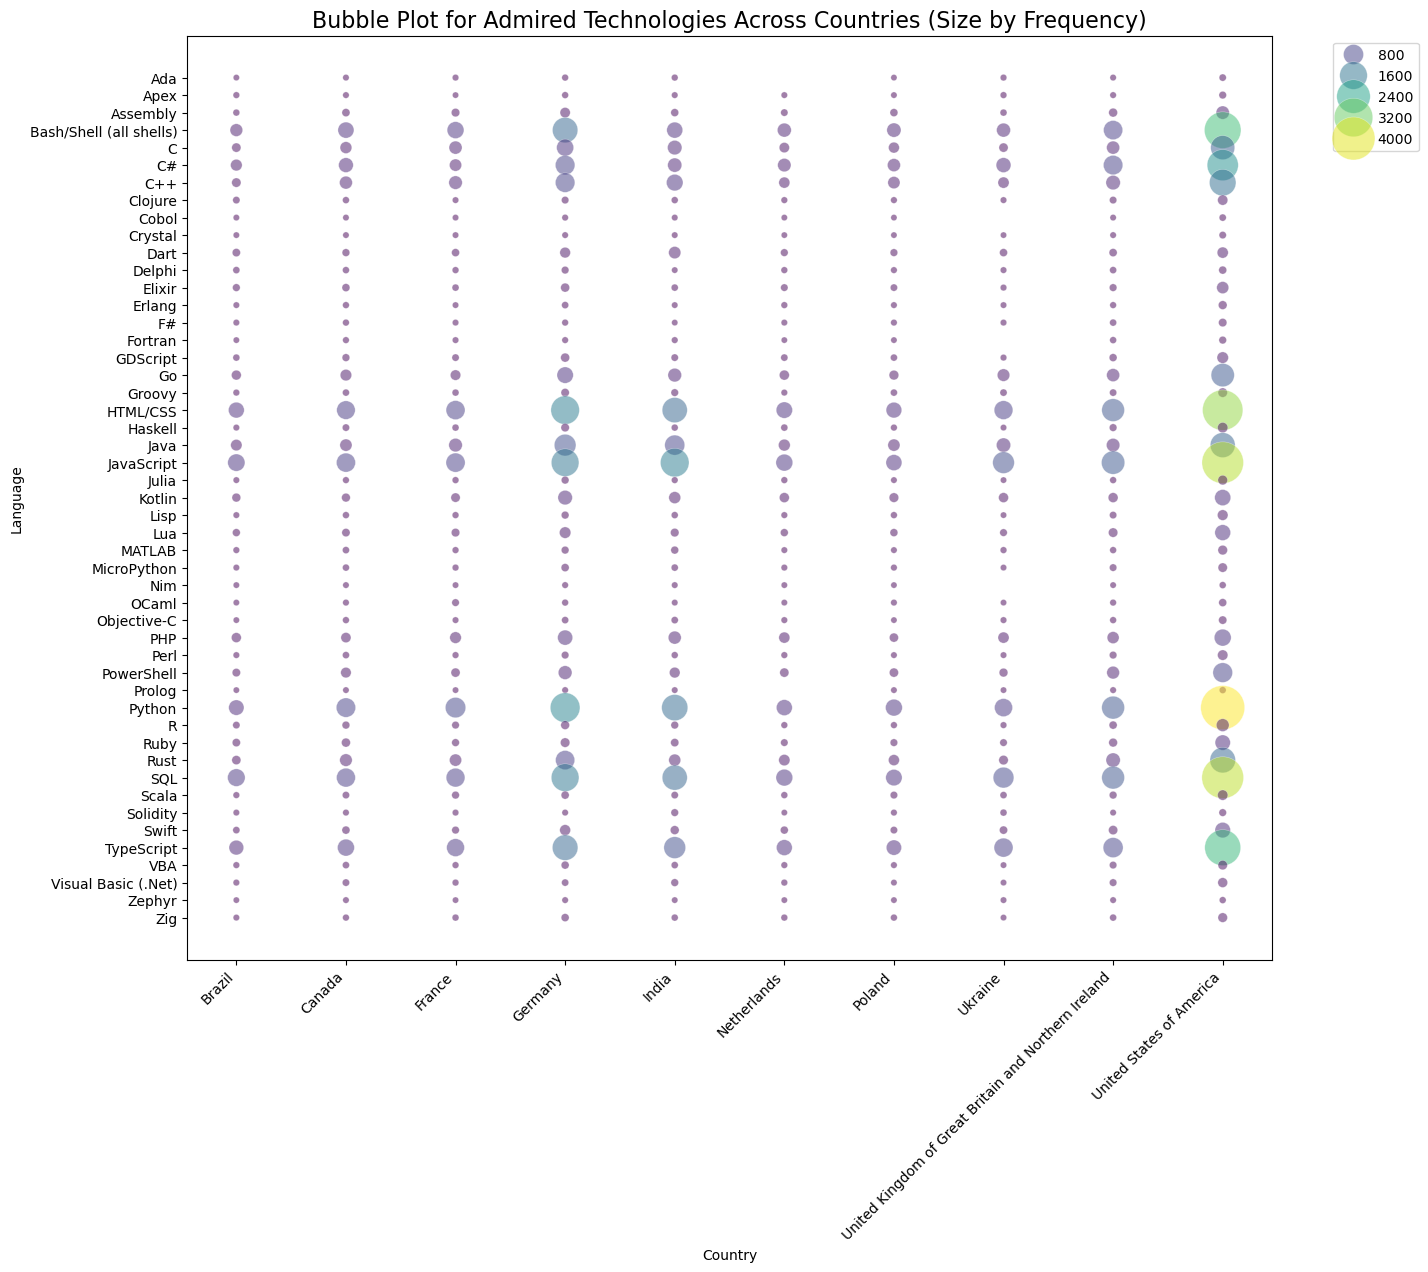

In [20]:
plt.figure(figsize=(14, 12))
sns.scatterplot(data = admired_counts, x = 'Country', y = 'Language', 
                size = 'Frequency', sizes = (20, 1000), hue = 'Frequency', 
                palette = 'viridis', alpha = 0.5)
plt.title('Bubble Plot for Admired Technologies Across Countries (Size by Frequency)', fontsize = 16)
plt.xticks(rotation=45, ha = 'right')
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
